# Verification — COVID-19 regional epidemic forecasting (Lin et al., 2021)

Two independent checks of the NYC-MSA compartmental model, for both the
**two-phase primary** (n=1, published MAP) and the **single-phase variant**
(n=0, independent de fit).

1. **Model-specification check.** For each model, BioNetGen generates the finite
   network and integrates it with CVODE. We re-implement the paper's compartmental
   ODEs **independently in SciPy** — the S→E1..E5→A/I→H→R/D system with the
   mixing/protected/quarantined states and the time-gated social-distancing,
   quarantine, and self-isolation rates — and confirm the daily new-case
   trajectory agrees with BioNetGen to ~1e-6.

2. **Reported-data check.** The models' daily new detected cases (the day-to-day
   increment of the cumulative detected-case count) are compared to the New York
   Times NYC daily case data. The two-phase model reproduces the published MAP
   forecast (Lin et al. 2021 Fig 3); the single-phase model captures the wave but
   overshoots the peak — motivating the second phase.

**Plot convention:** points = NYT data; lines = BioNetGen; open markers =
independent SciPy.


In [1]:

import os, glob, subprocess, tempfile
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

HERE = os.getcwd()
STEM = "covid19_regional_epidemic_forecasting_lin2021"
assert os.path.exists(os.path.join(HERE, STEM + ".bngl")), "run from the model folder"
REF = os.path.join(HERE, "reference")
BNGPATH = os.environ.get("BNGPATH") or os.path.expanduser("~/Simulations/BioNetGen-2.9.3")
BNG2PL = os.path.join(BNGPATH, "BNG2.pl")

def run_bng(model_file, t_end):
    block = open(os.path.join(HERE, model_file)).read().split("end model")[0] + "end model\n"
    acts = ("begin actions\ngenerate_network({overwrite=>1})\n"
            'simulate({method=>"ode",suffix=>"ode",t_start=>0,t_end=>%d,'
            'n_steps=>%d,print_functions=>1})\nend actions\n' % (t_end, t_end))
    d = tempfile.mkdtemp()
    open(os.path.join(d, "m.bngl"), "w").write(block + "\n" + acts)
    r = subprocess.run(["perl", BNG2PL, "m.bngl"], cwd=d, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError("BNG2.pl failed:\n" + r.stderr[-2000:])
    f = glob.glob(os.path.join(d, "*_ode.gdat"))[0]
    hdr = open(f).readline().lstrip("#").split()
    dat = np.loadtxt(f)
    return dat[:, 0], {n: dat[:, i] for i, n in enumerate(hdr)}

def load_nyt():
    lines = [l for l in open(os.path.join(REF, "lin2021_nyc_daily_cases_nyt.csv"))
             if not l.lstrip().startswith("#")]
    a = np.genfromtxt(lines, delimiter=",", names=True)
    return a["model_day"], a["daily_new_cases"]

# Fixed epidemiological constants (Lin 2021 Tables 2-3), shared by both models
FIX = dict(S0=19216182, I0=1, mb=0.1, rhoE=1.1, rhoA=0.9, kL=0.94, kQ=0.0038, jQ=0.4,
           fA=0.44, fH=0.054, fR=0.79, cA=0.26, cI=0.12, cH=0.17)

NAMES = ["S_M","S_P","E1_M","E1_P","E2_M","E2_P","E2_Q","E3_M","E3_P","E3_Q",
         "E4_M","E4_P","E4_Q","E5_M","E5_P","E5_Q","A_M","A_P","A_Q",
         "I_M","I_P","I_Q","H","R","D","fDCs"]
IDX = {n: i for i, n in enumerate(NAMES)}

def compartmental_ode(P, two_phase, death, clock_offset, t_end):
    """Independent SciPy integration of the paper's compartmental ODEs."""
    def rhs(tau, y):
        s = {n: y[i] for i, n in enumerate(NAMES)}
        d = {n: 0.0 for n in NAMES}
        t = clock_offset + tau
        if two_phase:
            U = 1.0 if t >= P["t0"] else 0.0
            if P["sigma"] <= t < P["tau1"]:
                Lam, Pp = P["lambda0"], P["p0"]
            elif P["tau1"] <= t < 200:
                Lam, Pp = P["lambda1"], P["p1"]
            else:
                Lam, Pp = 0.0, 0.0
            gate = t >= P["t0"]
        else:
            U = 1.0 if t > P["sigma"] else 0.0
            Lam = P["lambda0"] if t >= P["sigma"] else 0.0
            Pp = P["p0"] if t >= P["sigma"] else 0.0
            gate = t > P["t0"]
        kQf = P["kQ"] if gate else 0.0
        jQf = P["jQ"] if gate else 0.0
        cIf = P["cI"] if gate else 0.0
        E2to5M = s["E2_M"] + s["E3_M"] + s["E4_M"] + s["E5_M"]
        E2to5P = s["E2_P"] + s["E3_P"] + s["E4_P"] + s["E5_P"]
        phiM = (s["I_M"] + P["rhoE"] * E2to5M + P["rhoA"] * s["A_M"]) if gate else 0.0
        phiP = s["I_P"] + P["rhoE"] * E2to5P + P["rhoA"] * s["A_P"]
        def flux(src, dst, rate):
            f = rate * s[src]; d[src] -= f
            if dst is not None: d[dst] += f
        foiM = (P["beta"] / P["S0"]) * (phiM + P["mb"] * phiP)
        foiP = P["mb"] * (P["beta"] / P["S0"]) * (phiM + P["mb"] * phiP)
        flux("S_M", "E1_M", foiM); flux("S_P", "E1_P", foiP)
        fwd, rev = U * Lam * Pp, U * Lam * (1 - Pp)
        for x in ["S", "E1", "E2", "E3", "E4", "E5", "A", "I"]:
            flux(x + "_M", x + "_P", fwd); flux(x + "_P", x + "_M", rev)
        for x in ["E2", "E3", "E4", "E5", "A"]:
            flux(x + "_M", x + "_Q", P["kQ"]); flux(x + "_P", x + "_Q", P["kQ"])
        flux("I_M", "I_Q", kQf); flux("I_P", "I_Q", P["kQ"])
        flux("I_M", "I_Q", jQf); flux("I_P", "I_Q", P["jQ"])
        flux("E1_M", "E2_M", P["kL"]); flux("E1_P", "E2_P", P["kL"])
        for a, b in [("E2", "E3"), ("E3", "E4"), ("E4", "E5")]:
            for st in ["M", "P", "Q"]: flux(a + "_" + st, b + "_" + st, P["kL"])
        for st in ["M", "P", "Q"]:
            flux("E5_" + st, "A_" + st, P["kL"] * P["fA"])
            flux("E5_" + st, "I_" + st, P["kL"] * (1 - P["fA"]))
        for st in ["M", "P", "Q"]: flux("A_" + st, "R", P["cA"])
        flux("I_M", "R", cIf * (1 - P["fH"])); flux("I_P", "R", P["cI"] * (1 - P["fH"]))
        flux("I_Q", "R", P["cI"] * (1 - P["fH"]))
        flux("I_M", "H", cIf * P["fH"]); flux("I_P", "H", P["cI"] * P["fH"])
        flux("I_Q", "H", P["cI"] * P["fH"])
        flux("H", "R", P["cH"] * P["fR"])
        if death: flux("H", "D", P["cH"] * (1 - P["fR"]))
        d["fDCs"] += P["fD"] * (1 - P["fA"]) * P["kL"] * (s["E5_M"] + s["E5_P"])
        return np.array([d[n] for n in NAMES])
    y0 = np.zeros(len(NAMES)); y0[IDX["S_M"]] = P["S0"]; y0[IDX["I_M"]] = P["I0"]
    tg = np.arange(0, t_end + 1)
    sol = solve_ivp(rhs, (0, t_end), y0, t_eval=tg, method="LSODA", rtol=1e-9, atol=1e-6)
    S = {n: sol.y[IDX[n]] for n in NAMES}
    cumnum = P["fD"] * (S["I_M"] + S["I_P"] + S["I_Q"] + S["H"] + (1 - P["fA"]) * S["R"] + S["D"])
    return tg, S["fDCs"], cumnum

print("BNG2.pl exists:", os.path.exists(BNG2PL))


BNG2.pl exists: True


## 1. Two-phase primary (n=1) — published MAP, Fig 3

BioNetGen vs independent SciPy on the daily new-case trajectory, and model vs
NYT data over the full first wave (t = 0..170).


In [2]:

P_tp = dict(FIX, t0=32.831672, t_delta=0.072681, p0=0.872484, lambda0=0.098304,
            t_delta2=110.222846, p1=0.736221, lambda1=5.180963, beta=2.033369, fD=0.114511)
P_tp["sigma"] = P_tp["t0"] + P_tp["t_delta"]
P_tp["tau1"] = P_tp["t0"] + P_tp["t_delta"] + P_tp["t_delta2"]

t_bng, cols = run_bng(STEM + ".bngl", 170)
C_bng = cols["fDCs_Cum"]
_, fDCs_indep, _ = compartmental_ode(P_tp, two_phase=True, death=False, clock_offset=1, t_end=170)

daily_bng, daily_indep = np.diff(C_bng), np.diff(fDCs_indep)
big = daily_bng > 1
spec_tp = float((np.abs(daily_indep[big] - daily_bng[big]) / daily_bng[big]).max())
print("Model-spec (two-phase): daily-incidence max|relerr| BNG vs SciPy = %.2e" % spec_tp)

et, ey = load_nyt()
keep = (et <= 170) & (ey > 0)
m_at = np.interp(et, t_bng[1:], daily_bng)
rel_tp = np.abs(m_at[keep] - ey[keep]) / ey[keep]
print("Reported data (two-phase, published MAP): median |rel err| = %.1f%%  (peak model %.0f vs data %.0f/day)"
      % (np.median(rel_tp) * 100, daily_bng.max(), ey[et <= 170].max()))


Model-spec (two-phase): daily-incidence max|relerr| BNG vs SciPy = 4.44e-07
Reported data (two-phase, published MAP): median |rel err| = 18.4%  (peak model 14435 vs data 15925/day)


## 2. Single-phase variant (n=0) — independent de fit

Same two checks over the first wave (t = 0..151; fit window t = 50..151). The
fit observable here is `CumNum_detected_cases_Cum()`.


In [3]:

P_sp = dict(FIX, t0=26.633393, sigma=63.0, p0=0.591675, lambda0=9.160433,
            beta=0.537913, fD=0.883484)

t_bng_s, cols_s = run_bng(STEM + "_singlephase.bngl", 151)
C_bng_s = cols_s["CumNum_detected_cases_Cum"]
_, _, cumnum_indep = compartmental_ode(P_sp, two_phase=False, death=True, clock_offset=0, t_end=151)

daily_bng_s, daily_indep_s = np.diff(C_bng_s), np.diff(cumnum_indep)
bigs = daily_bng_s > 1
spec_sp = float((np.abs(daily_indep_s[bigs] - daily_bng_s[bigs]) / daily_bng_s[bigs]).max())
print("Model-spec (single-phase): daily-incidence max|relerr| BNG vs SciPy = %.2e" % spec_sp)

keeps = (et >= 50) & (et <= 151)
m_at_s = np.interp(et, t_bng_s[1:], daily_bng_s)
rel_sp = np.abs(m_at_s[keeps] - ey[keeps]) / ey[keeps]
print("Reported data (single-phase, de fit): median |rel err| = %.1f%%  (peak model %.0f vs data %.0f/day)"
      % (np.median(rel_sp) * 100, daily_bng_s.max(), ey[keeps].max()))


Model-spec (single-phase): daily-incidence max|relerr| BNG vs SciPy = 1.38e-06
Reported data (single-phase, de fit): median |rel err| = 16.3%  (peak model 22492 vs data 15925/day)


## 3. Verification figure

wrote /Users/wish/Code/BNGL-Models/models/covid19_regional_epidemic_forecasting_lin2021/verify_lin2021.png


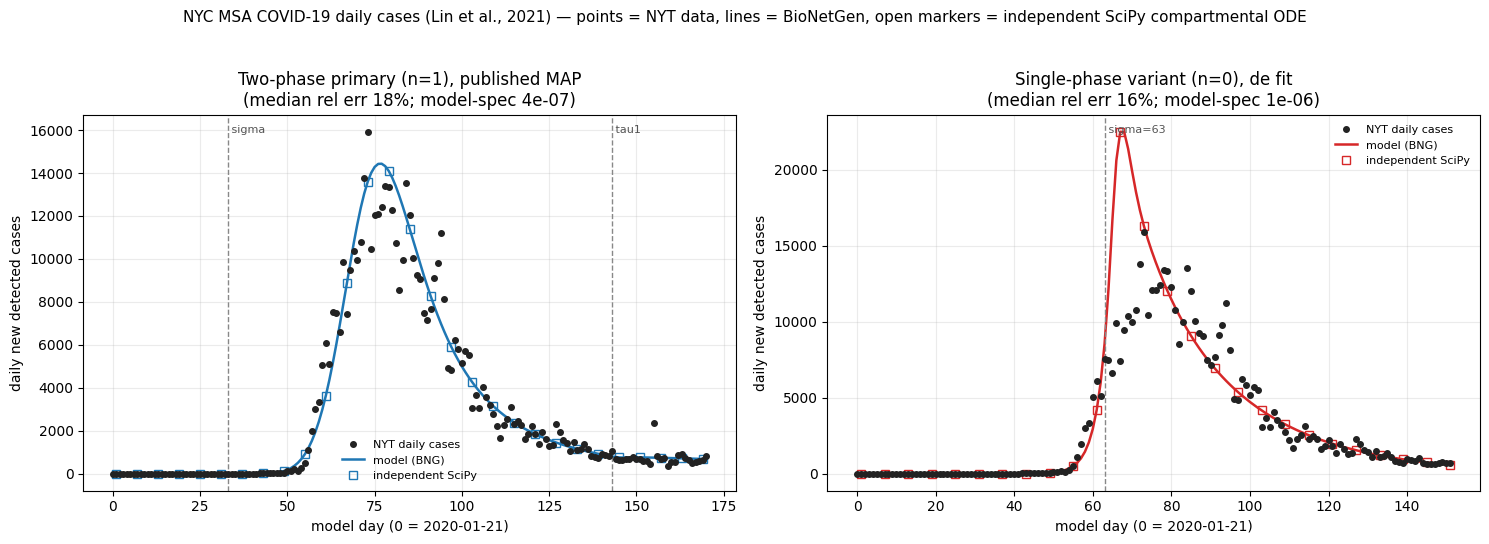

In [4]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
ss = slice(None, None, 6)

a = ax[0]
sel = et <= 170
a.plot(et[sel], ey[sel], "o", ms=4, color="#222", label="NYT daily cases", zorder=5)
a.plot(t_bng[1:], daily_bng, "-", color="#1f77b4", lw=1.8, label="model (BNG)")
a.plot(t_bng[1:][ss], daily_indep[ss], "s", mfc="none", mec="#1f77b4", ms=6, label="independent SciPy")
for x, lab in [(P_tp["sigma"], "sigma"), (P_tp["tau1"], "tau1")]:
    a.axvline(x, ls="--", color="#888", lw=1)
    a.text(x, a.get_ylim()[1] * 0.95, " " + lab, fontsize=8, color="#555")
a.set(xlabel="model day (0 = 2020-01-21)", ylabel="daily new detected cases",
      title="Two-phase primary (n=1), published MAP\n(median rel err %.0f%%; model-spec %.0e)"
            % (np.median(rel_tp) * 100, spec_tp))
a.legend(frameon=False, fontsize=8); a.grid(alpha=0.25)

b = ax[1]
sels = et <= 151
b.plot(et[sels], ey[sels], "o", ms=4, color="#222", label="NYT daily cases", zorder=5)
b.plot(t_bng_s[1:], daily_bng_s, "-", color="#d62728", lw=1.8, label="model (BNG)")
b.plot(t_bng_s[1:][ss], daily_indep_s[ss], "s", mfc="none", mec="#d62728", ms=6, label="independent SciPy")
b.axvline(P_sp["sigma"], ls="--", color="#888", lw=1)
b.text(P_sp["sigma"], b.get_ylim()[1] * 0.95, " sigma=63", fontsize=8, color="#555")
b.set(xlabel="model day (0 = 2020-01-21)", ylabel="daily new detected cases",
      title="Single-phase variant (n=0), de fit\n(median rel err %.0f%%; model-spec %.0e)"
            % (np.median(rel_sp) * 100, spec_sp))
b.legend(frameon=False, fontsize=8); b.grid(alpha=0.25)

fig.suptitle("NYC MSA COVID-19 daily cases (Lin et al., 2021) — points = NYT data, "
             "lines = BioNetGen, open markers = independent SciPy compartmental ODE", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.95))
out_png = os.path.join(HERE, "verify_lin2021.png")
fig.savefig(out_png, dpi=130)
print("wrote", out_png)


## Summary

- **Model specification:** for both models the independent SciPy integration of
  the paper's compartmental ODEs reproduces BioNetGen's daily new-case trajectory
  to ~1e-6 — the `.bngl` rules encode exactly the intended S→E→A/I→H→R/D dynamics
  with the M/P/Q states and time-gated social distancing, quarantine, and
  self-isolation.
- **Reported data:** the two-phase primary reproduces the published NYC MAP
  forecast (Lin et al. 2021 Fig 3) over the full first wave (median ~18% rel err,
  peak within ~9%). The single-phase variant captures the wave (median ~16%) but
  overshoots the peak (~22,500 vs ~15,900 cases/day) and cannot hold the plateau
  — demonstrating why the published forecast and the two-phase primary are
  preferred.
